# Homework 4 Solution

This notebook shows one possible solution for the multivariable linear regression homework based on the China panel dataset.

For readability, this solution creates a few short English aliases for Chinese variable names while keeping the original source columns intact.

In [1]:
from pathlib import Path

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    return current

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
ASSETS_DIR = PROJECT_ROOT / "assets"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025')

In [2]:
MODULE_OUTPUT_DIR = OUTPUT_DIR / "homework_04"
MODULE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODULE_OUTPUT_DIR

PosixPath('/Users/hanyu/Documents/GitHub/big-data-analysis-2025/outputs/homework_04')

**Optional setup**

In [3]:
%pip install -q openpyxl seaborn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(
    DATA_DIR / "china" / "china_panel_data.xlsx",
    sheet_name=0,
)

province_map = pd.read_csv(DATA_DIR / "china" / "province_name_mapping.csv")

df = df.merge(province_map, left_on="地区", right_on="region_cn", how="left")
df.head()

,序号,地区,年份,国内生产总值（当年价）（亿元）,第三产业增加值（亿元）,总人口（万人）,城镇人口（万人）,城镇就业人员数（万人）,货物出口金额（万美元）,货物进口金额（万美元）,一般预算支出（亿元）,互联网宽带接入用户（万户）,有电子商务交易活动企业占总企业数比重（%）,电子商务销售额（亿元）,电子商务采购额（亿元）,R&D经费（万元）,数字普惠金融指数,region_cn,region_en
0,1,北京,2013,19800.81,14986.43,2125,1836,1162.7905,6309756.100,36589825.10,4173.6563,480.400,7.4626,7467.6372,4877.7164,2130617.5,229.57001,北京,Beijing
1,1,北京,2014,21330.83,16627.04,2171,1878,1309.2000,6233842.000,35318018.00,4524.6700,482.400,12.5790,9012.4132,7563.9099,2335010.1,235.22000,北京,Beijing
2,1,北京,2015,23014.59,18331.74,2188,1897,1415.7448,5466681.700,26477375.20,5737.7000,491.900,17.1000,10530.5028,9534.1257,2440874.5,379.48001,北京,Beijing
3,1,北京,2016,25669.13,20594.90,2195,1904,1476.6700,5202284.300,23032611.70,6406.7700,475.760,18.0000,12026.6910,9340.6360,2548433.3,329.89999,北京,Beijing
4,1,北京,2017,28014.94,22567.76,2194,1907,1547.1100,5850304.551,26521615.92,6824.5284,541.936,19.0000,18385.6627,11055.8269,2690851.2,326.01999,北京,Beijing


In [5]:
df.columns

Index(['序号', '地区', '年份', '国内生产总值（当年价）（亿元）', '第三产业增加值（亿元）', '总人口（万人）',
       '城镇人口（万人）', '城镇就业人员数（万人）', '货物出口金额（万美元）', '货物进口金额（万美元）', '一般预算支出（亿元）',
       '互联网宽带接入用户（万户）', '有电子商务交易活动企业占总企业数比重（%）', '电子商务销售额（亿元）', '电子商务采购额（亿元）',
       'R&D经费（万元）', '数字普惠金融指数', 'region_cn', 'region_en'],
      dtype='object')

# Q1. Select regression variables and produce descriptive statistics.

A common choice is to use GDP per capita as the dependent variable and variables such as tertiary-industry value added, exports, e-commerce activity, and R&D expenditure as explanatory variables.

When the standard deviation is very large, a log transformation is often useful to reduce scale differences and potential heteroskedasticity.

In [6]:
df["year"] = df["年份"]
df["gdp_per_capita"] = df["国内生产总值（当年价）（亿元）"] / df["总人口（万人）"]
df["lngdpc"] = np.log(df["gdp_per_capita"])
df["urbanization_rate"] = df["城镇人口（万人）"] / df["总人口（万人）"] * 100
df["lnrd_pc"] = np.log(df["R&D经费（万元）"] / df["总人口（万人）"])
df["digital_finance_index"] = df["数字普惠金融指数"]
df["ecommerce_share_pct"] = df["有电子商务交易活动企业占总企业数比重（%）"]
df["lntrade_pc"] = np.log(
    (df["货物出口金额（万美元）"] + df["货物进口金额（万美元）"])
    / df["总人口（万人）"]
)

df[[
    "gdp_per_capita",
    "lngdpc",
    "urbanization_rate",
    "lnrd_pc",
    "digital_finance_index",
    "ecommerce_share_pct",
    "lntrade_pc",
]].describe().T



,count,mean,std,min,25%,50%,75%,max
gdp_per_capita,310.0,6.360543,3.052578,2.226558,4.265632,5.537904,7.304525,19.052610
lngdpc,310.0,1.755474,0.422244,0.800457,1.450590,1.711616,1.988494,2.947204
urbanization_rate,310.0,60.445442,12.357726,23.974763,52.896139,59.676581,66.460268,89.583333
lnrd_pc,310.0,6.196244,1.081499,2.064981,5.525284,6.271283,7.056150,8.165014
digital_finance_index,310.0,355.020226,64.382155,217.929990,313.645008,379.225005,404.832515,462.230010
ecommerce_share_pct,310.0,8.874247,3.762432,1.500700,6.000000,8.900000,11.200000,24.720500
lntrade_pc,310.0,7.233709,1.279024,4.019068,6.451652,6.941762,7.983492,10.137977


# Q2. Visualize selected variables. Different regions should be visually distinguishable.

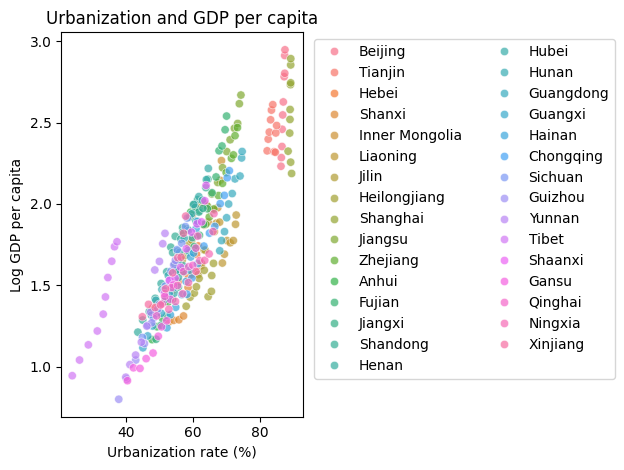

In [7]:
sns.scatterplot(
    data=df,
    x="urbanization_rate",
    y="lngdpc",
    hue="region_en",
    alpha=0.7,
)
plt.xlabel("Urbanization rate (%)")
plt.ylabel("Log GDP per capita")
plt.title("Urbanization and GDP per capita")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(MODULE_OUTPUT_DIR / "scatter_urbanization_lngdpc.png", bbox_inches="tight")



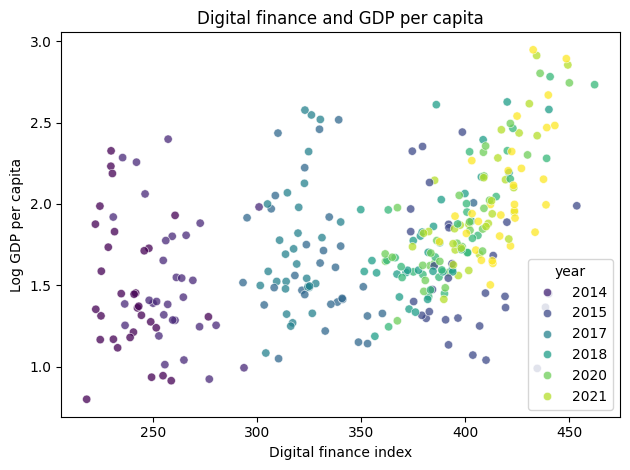

In [8]:
sns.scatterplot(
    data=df,
    x="digital_finance_index",
    y="lngdpc",
    hue="year",
    palette="viridis",
    alpha=0.75,
)
plt.xlabel("Digital finance index")
plt.ylabel("Log GDP per capita")
plt.title("Digital finance and GDP per capita")
plt.tight_layout()
plt.savefig(MODULE_OUTPUT_DIR / "scatter_digital_finance_lngdpc.png", bbox_inches="tight")



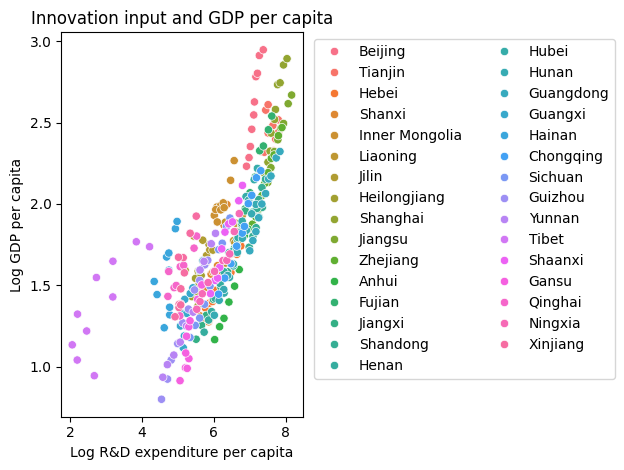

In [9]:
sns.scatterplot(data=df, x="lnrd_pc", y="lngdpc", hue="region_en")
plt.xlabel("Log R&D expenditure per capita")
plt.ylabel("Log GDP per capita")
plt.title("Innovation input and GDP per capita")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(MODULE_OUTPUT_DIR / "scatter_lnrdpc_lngdpc.png", bbox_inches="tight")



In [10]:
df["area_group"] = "Non-coastal region"

df.loc[df["地区"].isin(["上海", "江苏", "浙江", "福建", "广东"]), "area_group"] = "Southeastern coastal region"

df["area_group"].unique()

array(['Non-coastal region', 'Southeastern coastal region'], dtype=object)

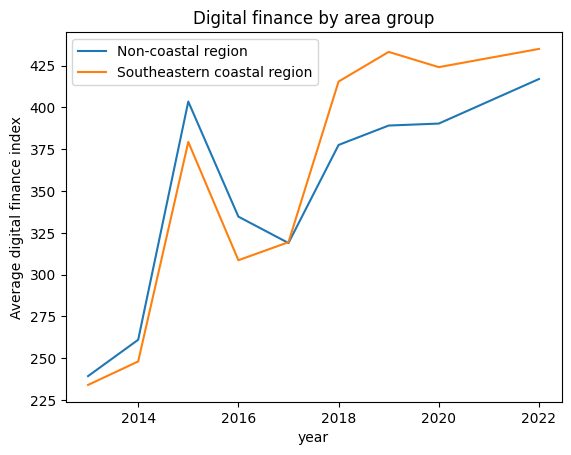

In [11]:
sns.lineplot(
    data=df,
    x="year",
    y="digital_finance_index",
    hue="area_group",
    estimator="mean",
    errorbar=None,
)
plt.ylabel("Average digital finance index")
plt.title("Digital finance by area group")
plt.legend(loc="best")
plt.savefig(MODULE_OUTPUT_DIR / "line_digital_finance_by_area_group.png", bbox_inches="tight")



# Q3. Run OLS regressions using the selected variables.

In [12]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

# Define the dependent variable.
y = df[["lngdpc"]]

# Define the independent variables.
X1 = df[["ecommerce_share_pct"]]
X2 = df[["ecommerce_share_pct", "digital_finance_index"]]
X3 = df[["ecommerce_share_pct", "digital_finance_index", "urbanization_rate"]]
X4 = df[["ecommerce_share_pct", "digital_finance_index", "urbanization_rate", "lnrd_pc"]]

# Add constant terms.
X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

# Fit OLS models.
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

# Create a summary table with significance stars.
reg = summary_col(
    [model1, model2, model3, model4],
    stars=True,
    model_names=["Model 1", "Model 2", "Model 3", "Model 4"],
    float_format="%0.3f",
    info_dict={"N": lambda result: result.nobs, "R2": lambda result: f"{result.rsquared:.3f}"},
)

reg_df = reg.tables[0].reset_index(drop=False)
reg_df.to_excel(MODULE_OUTPUT_DIR / "Homework4_regression_results.xlsx", index=False)

reg_df



,index,Model 1,Model 2,Model 3,Model 4
0,const,1.308***,0.775***,-0.344***,-0.487***
1,,(0.055),(0.116),(0.069),(0.071)
2,ecommerce_share_pct,0.050***,0.036***,0.015***,0.016***
3,,(0.006),(0.006),(0.003),(0.003)
4,digital_finance_index,,0.002***,0.001***,0.001***
5,,,(0.000),(0.000),(0.000)
6,urbanization_rate,,,0.027***,0.021***
7,,,,(0.001),(0.001)
8,lnrd_pc,,,,0.080***
9,,,,,(0.015)
